# Sheet 3: Generative and Predictive Modeling with Energy-Based Models (EBMs)

**Advanced Deep Learning — Winter 2025/26**  

---

In this notebook, we explore **Energy-Based Models (EBMs)** — a fundamental and versatile framework for generative probabilistic modeling. We apply them to a dataset of **historical printed glyphs** (scans of individual lowercase and uppercase characters from one of the earliest letterpress printings).

### What we will cover:
1. **EBM Theory** — Gibbs distributions, the partition function, and MLE training
2. **SGLD Sampling** — Stochastic Gradient Langevin Dynamics for approximate inference
3. **Joint Energy-Based Models (JEM)** — combining generative and predictive modeling
4. **Image Synthesis** — generating new glyph images from noise
5. **OOD Detection** — using energy scores to identify out-of-distribution samples

> **Inspiration:** This notebook follows the style of the [UvA DL Notebooks](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html), upon which parts of this exercise are based.

## Setup & Imports

In [ ]:
## Standard libraries
import os
import numpy as np
import tqdm
import glob
import pandas as pd
import argparse
from typing import Union, Dict

## Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## PyTorch & DL
import torch
import torch.utils.data as data
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
from torchvision import transforms

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

## Misc
from sklearn.metrics import roc_auc_score

# Reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

RESULTS_DIR = "./EBM/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

---

## Part 1: Theory — What Are Energy-Based Models?

### 1.1 The Core Idea

In **generative modeling**, we want to learn a statistical model $q_\theta(\mathbf{x})$ that approximates the true data distribution $p(\mathbf{x})$. An EBM achieves this by establishing a mapping from data points to **scalar energy values**:

$$q_\theta(\mathbf{x}) = \frac{\exp(-E_\theta(\mathbf{x}))}{Z_\theta}$$

The intuition is simple:
- **Low energy** $\rightarrow$ **High probability** (the model thinks this is a likely data point)
- **High energy** $\rightarrow$ **Low probability** (unlikely / out-of-distribution)

$Z_\theta = \int_x \exp(-E_\theta(\mathbf{x}))\, dx$ is the **partition function** (normalization constant) that ensures $q_\theta$ integrates to 1.

In code (and in the literature), we often write the neural network as $f_\theta(\mathbf{x}) = -E_\theta(\mathbf{x})$ — so the network models the **negative** energy.

### 1.2 The Partition Function Problem

The partition function $Z_\theta$ is **computationally intractable** for high-dimensional data like images, since it requires integrating over the entire input space. This is the central challenge of EBM training.

**Solutions:**
- For problems expressible as *energy ratios* (e.g., denoising): we can cancel $Z_\theta$
- For *product of experts* models: decompose into analytically tractable sub-problems
- **In most cases:** approximate $Z_\theta$ using samples from $q_\theta$

### 1.3 Maximum Likelihood Training

We minimize the **negative log-likelihood**:

$$\mathcal{L}_{ML}(\theta; p) = \mathbb{E}_{p(\mathbf{x})}[-\log q_\theta(\mathbf{x})]$$

Taking the gradient yields a beautiful **contrastive** expression:

$$\frac{\partial \mathcal{L}_{ML}}{\partial \theta} = \underbrace{\mathbb{E}_{p(\mathbf{x})}\left[\frac{\partial E_\theta(\mathbf{x})}{\partial \theta}\right]}_{\text{push down energy of real data}} - \underbrace{\mathbb{E}_{q_\theta(\mathbf{x})}\left[\frac{\partial E_\theta(\mathbf{x})}{\partial \theta}\right]}_{\text{push up energy of synthesized data}}$$

The first term says: *lower the energy of real training samples*. The second term says: *raise the energy of model-generated samples*. Training converges when $p(\mathbf{x}) = q_\theta(\mathbf{x})$.

In practice, we approximate both expectations with finite sample sets:

$$\approx \frac{1}{n}\sum_{i=1}^{n} \frac{\partial E_\theta(\mathbf{x}_i)}{\partial \theta} - \frac{1}{\tilde{n}}\sum_{i=1}^{\tilde{n}} \frac{\partial E_\theta(\tilde{\mathbf{x}}_i)}{\partial \theta}$$

where $\{\mathbf{x}_i\}$ are training samples and $\{\tilde{\mathbf{x}}_i\}$ are synthesized samples from $q_\theta$.

<div align="center">

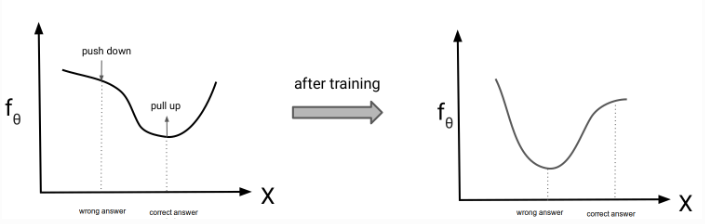

</div>

## Part 2: Sampling with Stochastic Gradient Langevin Dynamics (SGLD)

To approximate the partition function, we need samples from $q_\theta(\mathbf{x})$. We use **Stochastic Gradient Langevin Dynamics (SGLD)**, which combines gradient-based optimization with Brownian noise:

$$\mathbf{x}^0 \sim \pi(\mathbf{x})$$
$$\mathbf{x}^{k+1} = \mathbf{x}^k - \frac{\eta}{2} \frac{\partial E_\theta(\mathbf{x}^k)}{\partial \mathbf{x}^k} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \eta)$$

- The **gradient term** drives the chain toward high-probability regions (low energy)
- The **noise term** (Brownian motion) prevents collapse into local modes and ensures full exploration

<div align="center">

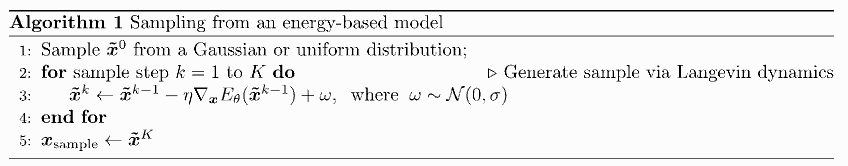

</div>

### Initialization strategies $\pi(\mathbf{x})$:

| Strategy | $\pi(\mathbf{x})$ | Description |
|---|---|---|
| Contrastive Divergence | $p_{\text{train}}(\mathbf{x})$ | Start from real training samples |
| Persistent Chain | $q_\theta^{\text{prev}}(\mathbf{x})$ | Continue chains from last epoch |
| Short-run MCMC | $\mathcal{N}(\mu, \sigma)$ | Start fresh from Gaussian noise |

### Training Tricks

**Reservoir Sampling (Replay Buffer):** A hybrid approach — with probability $p$ (e.g., 95%), initialize from previously synthesized images stored in a buffer; otherwise (5%), start from fresh Gaussian noise. This combines the stability of persistent chains with the exploration benefits of short-run MCMC.

**L2 Regularization of Energy Magnitudes:** Penalize large energy values to prevent steep, non-smooth energy surfaces:
$$\mathcal{L}_{\text{reg}} = \alpha \cdot \mathbb{E}[E_{\text{real}}^2 + E_{\text{synth}}^2]$$



---

## Part 3: Data Loading

The dataset contains **16,171 grayscale images** of historical glyphs across **42 classes** (lowercase + uppercase characters from early letterpress printing), split 70/15/15 into train/val/test. Images are normalized to 56×56 px.

In [ ]:
# ============================================================
#  data.py — Dataset utilities
# ============================================================

class TransformTensorDataset(data.Dataset):
    """TensorDataset with support for transforms."""

    def __init__(self, *tensors, transform=None):
        assert all(tensors[0].size(0) == t.size(0) for t in tensors)
        self.tensors = tensors
        self.transform = transform

    def __getitem__(self, index):
        x = self.tensors[0][index]
        if self.transform:
            x = self.transform(x)
        try:
            y = self.tensors[1][index]
        except IndexError:
            y = -1
        return x, y

    def __len__(self):
        return self.tensors[0].size(0)


def minmax(x):
    return (x - x.min()) / (x.max() - x.min())


def get_datasets(data_dir: Union[str, Path]) -> Dict[str, TransformTensorDataset]:
    with open(Path(data_dir) / 'train.npy', 'rb') as f:
        X_train, y_train = np.load(f), np.load(f)
    with open(Path(data_dir) / 'val.npy', 'rb') as f:
        X_val, y_val = np.load(f), np.load(f)
    with open(Path(data_dir) / 'test.npy', 'rb') as f:
        X_test, y_test = np.load(f), np.load(f)
    with open(Path(data_dir) / 'ood_ta.npy', 'rb') as f:
        ood_ta = np.load(f)
    with open(Path(data_dir) / 'ood_tb.npy', 'rb') as f:
        ood_tb = np.load(f)

    X_train_t = torch.from_numpy(X_train).float().unsqueeze(1)
    y_train_t = torch.from_numpy(y_train).long()
    X_val_t   = torch.from_numpy(X_val).float().unsqueeze(1)
    y_val_t   = torch.from_numpy(y_val).long()
    X_test_t  = torch.from_numpy(X_test).float().unsqueeze(1)
    y_test_t  = torch.from_numpy(y_test).long()

    X_ood_ta = torch.from_numpy(ood_ta).float().unsqueeze(1)
    X_ood_tb = torch.from_numpy(ood_tb).float().unsqueeze(1)

    num_noise = len(ood_ta)
    X_noise = torch.rand((num_noise,) + X_ood_ta.shape[1:], dtype=torch.float32)

    std_transform = transforms.Compose([
        transforms.Lambda(minmax),
        transforms.Resize(size=56, antialias=True),
        transforms.CenterCrop(size=56),
        transforms.Normalize((0.5,), (0.5,))
    ])

    return {
        'train':     TransformTensorDataset(X_train_t, y_train_t, transform=std_transform),
        'val':       TransformTensorDataset(X_val_t,   y_val_t,   transform=std_transform),
        'test':      TransformTensorDataset(X_test_t,  y_test_t,  transform=std_transform),
        'ood_ta':    TransformTensorDataset(X_ood_ta,             transform=std_transform),
        'ood_tb':    TransformTensorDataset(X_ood_tb,             transform=std_transform),
        'ood_noise': TransformTensorDataset(X_noise,              transform=std_transform),
    }

In [ ]:
# ── Load data ──────────────────────────────────────────────
DATA_DIR = "./data/GLYPHS"  # ← update if your data lives elsewhere

datasets = get_datasets(DATA_DIR)
print("Dataset sizes:")
for name, ds in datasets.items():
    print(f"  {name:12s}: {len(ds):,} samples")

In [ ]:
# ── Visualize some training examples ───────────────────────
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img, label = datasets['train'][i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"cls {label.item()}", fontsize=7)
    ax.axis('off')
plt.suptitle("Sample training glyphs (56×56 px, normalised to [−1, 1])", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## Exercise 3.2: The Energy Function — Parameterizing $E_\theta$ with a Neural Network

We parameterize the energy function with a **shallow CNN**. Recall:

- The network computes $f_\theta(\mathbf{x}) = -E_\theta(\mathbf{x})$ — the **negative energy** (higher output = lower energy = higher probability)
- For **unconditional EBM / JEM**: we marginalize over classes using LogSumExp:
  $$E_\theta(\mathbf{x}) = -\log\sum_y \exp(f_\theta(\mathbf{x})[y])$$
- For **conditional JEM** with known label $y$: we select the $y$-th logit directly:
  $$E_\theta(\mathbf{x}, y) = -f_\theta(\mathbf{x})[y]$$

The CNN uses **Swish activations** ($x \cdot \sigma(x)$), which are smooth and perform well in energy-based settings.

In [ ]:
# ============================================================
#  model.py — ShallowCNN energy function
# ============================================================

class Swish(nn.Module):
    """Swish activation: x * sigmoid(x) — smooth, non-monotonic, works well in EBMs."""
    def forward(self, x):
        return x * torch.sigmoid(x)


class ShallowCNN(nn.Module):
    """
    Shallow CNN that acts as the energy function f_theta(x) = -E_theta(x).

    Architecture:
        5 conv layers with Swish activations → adaptive avg pool → linear projection to num_classes logits
    """
    def __init__(self, hidden_features=32, num_classes=42, **kwargs):
        super().__init__()
        c1, c2, c3 = hidden_features, hidden_features * 2, hidden_features * 4

        self.cnn_layers = nn.Sequential(
            nn.Conv2d(1, c1, kernel_size=5, stride=2, padding=4), Swish(),
            nn.Conv2d(c1, c2, kernel_size=3, stride=2, padding=1), Swish(),
            nn.Conv2d(c2, c3, kernel_size=3, stride=2, padding=1), Swish(),
            nn.Conv2d(c3, c3, kernel_size=3, stride=2, padding=1), Swish(),
            nn.Conv2d(c3, c3, kernel_size=3, stride=2, padding=1), Swish(),
        )
        self.fc_layers = nn.Sequential(nn.Flatten(), nn.Linear(c3, num_classes))

    def get_logits(self, x: torch.Tensor) -> torch.Tensor:
        """Return class logits f_theta(x) ∈ R^{num_classes} — used for classification."""
        # (a) Extract spatial features
        z = self.cnn_layers(x)
        # (a) Global average pool to collapse spatial dims → (B, C, 1, 1)
        z = F.adaptive_avg_pool2d(z, 1)
        # (a) Linear layer → logits (B, num_classes)
        return self.fc_layers(z)

    def forward(self, x: torch.Tensor, y: torch.Tensor = None) -> torch.Tensor:
        """
        Compute energy E_theta(x) or E_theta(x,y).

        Args:
            x: Input image tensor of shape (B, 1, H, W)
            y: Optional class label tensor of shape (B,)
               - None  → unconditional EBM / JEM: E(x) = -LogSumExp(f(x))
               - given → conditional JEM:          E(x,y) = -f(x)[y]

        Returns:
            energy: Scalar energy per sample, shape (B,)
        """
        logits = self.get_logits(x)  # (B, num_classes)

        if y is None:
            # (b) Unconditional: marginalise over y via LogSumExp
            # High logits → large LogSumExp → small (more negative) energy → higher p(x)
            energy = -torch.logsumexp(logits, dim=1)          # (B,)
        else:
            # (b) Conditional: pick the logit for the true class
            # y shape: (B,) → unsqueeze to (B,1) for gather → squeeze back to (B,)
            energy = -logits.gather(1, y.unsqueeze(1)).squeeze(1)  # (B,)

        return energy

In [ ]:
# ── Sanity check ───────────────────────────────────────────
cnn = ShallowCNN(hidden_features=32, num_classes=42)
dummy_x = torch.randn(4, 1, 56, 56)
dummy_y = torch.randint(0, 42, (4,))

print("Logits shape:           ", cnn.get_logits(dummy_x).shape)        # (4, 42)
print("Unconditional energy:   ", cnn(dummy_x).shape)                   # (4,)
print("Conditional energy:     ", cnn(dummy_x, dummy_y).shape)          # (4,)

total_params = sum(p.numel() for p in cnn.parameters())
print(f"\nTotal parameters: {total_params:,}")

---

## Exercise 3.3: SGLD Sampler with Reservoir Sampling

The `MCMCSampler` implements non-persistent short-run MCMC with a **replay buffer**:

1. **Initialization** — Draw ~5% fresh Gaussian noise; fill the rest from the buffer of previous synthetic images
2. **SGLD loop** — For each of $K$ steps:
   - Add small Brownian noise: $\mathbf{x} \leftarrow \mathbf{x} + \epsilon$, $\epsilon \sim \mathcal{N}(0, \sigma_{\text{noise}})$
   - Compute energy gradient: $\nabla_{\mathbf{x}} E_\theta(\mathbf{x})$
   - Gradient descent on energy: $\mathbf{x} \leftarrow \mathbf{x} - \eta \cdot \nabla_{\mathbf{x}} E_\theta(\mathbf{x})$
3. **Buffer update** — Store the final synthesized images back into the class-specific buffer (FIFO, capped at `cbuffer_size`)

In [ ]:
# ============================================================
#  MCMCSampler — SGLD with Reservoir Sampling
# ============================================================

class MCMCSampler:
    """
    MCMC sampler using Stochastic Gradient Langevin Dynamics (SGLD).

    Combines non-persistent short-run MCMC with reservoir (replay buffer) sampling
    to stabilise training and improve convergence.
    """

    def __init__(self, model, img_shape, sample_size, num_classes, cbuffer_size=256):
        """
        Args:
            model:        CNN energy function
            img_shape:    Tuple (C, H, W)
            sample_size:  Number of images to synthesise per call
            num_classes:  Number of classes (one buffer per class)
            cbuffer_size: Max images per class in the replay buffer
        """
        self.model = model
        self.img_shape = img_shape
        self.sample_size = sample_size
        self.num_classes = num_classes
        self.cbuffer_size = cbuffer_size

        # (a) Reservoir buffer: one list per class
        self.examples = [[] for _ in range(num_classes)]

    def synthesize_samples(
        self,
        clabel=None,
        steps=60,
        step_size=10,
        return_img_per_step=False,
    ):
        """
        Run SGLD to synthesise images from the current q_theta.

        Args:
            clabel:             Optional class labels (B,) for conditional sampling
            steps:              Number of SGLD steps K
            step_size:          SGLD step size η
            return_img_per_step: If True, return all intermediate images (for visualisation)

        Returns:
            Synthesised images of shape (B, C, H, W),
            or (K, B, C, H, W) if return_img_per_step=True
        """
        # Freeze model weights — we only differentiate w.r.t. x
        is_training = self.model.training
        self.model.eval()
        for p in self.model.parameters():
            p.requires_grad = False

        had_grads = torch.is_grad_enabled()
        torch.set_grad_enabled(True)

        # ── (a) Reservoir Sampling: initialise x^0 ─────────────────
        # ~5% fresh Gaussian noise, ~95% from buffer
        n_new = np.random.binomial(self.sample_size, 0.05)
        n_old = self.sample_size - n_new

        rand_imgs = torch.rand((n_new,) + self.img_shape).to(device) * 2 - 1  # Uniform in [-1,1]

        old_imgs = []
        if n_old > 0:
            if clabel is not None:  # Conditional: sample from class-specific buffers
                for label in clabel[:n_old]:
                    buf = self.examples[label.item()]
                    if buf:
                        old_imgs.append(buf[np.random.randint(len(buf))])
                    else:
                        old_imgs.append(torch.rand(self.img_shape).to(device) * 2 - 1)
                old_imgs = torch.stack(old_imgs)
            else:                    # Unconditional: sample from any buffer
                all_imgs = [img for sub in self.examples for img in sub]
                if all_imgs:
                    idx = np.random.choice(len(all_imgs), size=n_old)
                    old_imgs = torch.stack([all_imgs[i] for i in idx])
                else:
                    old_imgs = torch.rand((n_old,) + self.img_shape).to(device) * 2 - 1
            old_imgs = old_imgs.to(device)

        inp_imgs = torch.cat([rand_imgs, old_imgs], dim=0).detach() if n_old > 0 else rand_imgs.detach()
        inp_imgs.requires_grad = True

        imgs_per_step = []

        # ── (b)+(c) SGLD loop ───────────────────────────────────────
        noise_scale = 0.005
        for _ in range(steps):
            # Brownian noise for exploration
            inp_imgs.data.add_(torch.randn_like(inp_imgs) * noise_scale).clamp_(-1.0, 1.0)

            # (b) Energy + gradient dE/dx
            energy = self.model(inp_imgs, clabel)
            grad = torch.autograd.grad(energy.sum(), inp_imgs)[0]

            # (c) Gradient descent on energy (= ascent toward high probability)
            grad.data.clamp_(-0.03, 0.03)           # stability: clip gradients
            inp_imgs.data.add_(-step_size * grad.data).clamp_(-1.0, 1.0)
            inp_imgs.grad = None

            if return_img_per_step:
                imgs_per_step.append(inp_imgs.clone().detach())

        # ── Update replay buffer ────────────────────────────────────
        final = inp_imgs.detach().cpu()
        if clabel is not None:
            for i, label in enumerate(clabel):
                buf = self.examples[label.item()]
                buf.append(final[i])
                if len(buf) > self.cbuffer_size:
                    buf.pop(0)
        else:
            for i in range(self.sample_size):
                cls = np.random.randint(self.num_classes)
                self.examples[cls].append(final[i])
                if len(self.examples[cls]) > self.cbuffer_size:
                    self.examples[cls].pop(0)

        # Restore model state
        for p in self.model.parameters():
            p.requires_grad = True
        self.model.train(is_training)
        torch.set_grad_enabled(had_grads)

        return torch.stack(imgs_per_step, dim=0) if return_img_per_step else inp_imgs



## Part 4: Joint Energy-Based Model (JEM)

### The Key Insight

Grathwohl et al. (2020) showed that **any classifier can secretly be an EBM**. The trick is to reinterpret the classifier's logits as unnormalized log-densities of the joint distribution:

$$q_\theta(\mathbf{x}, y) = \frac{\exp(f_\theta(\mathbf{x})[y])}{Z(\theta)}$$

Factorizing the log joint density gives a clean decomposition:

$$\log q_\theta(\mathbf{x}, y) = \underbrace{\log q_\theta(\mathbf{x})}_{\text{generative loss (EBM)}} + \underbrace{\log q_\theta(y|\mathbf{x})}_{\text{classification loss (cross-entropy)}}$$

The two losses are:
- **$p(\mathbf{x})$ step:** Contrastive divergence + L2 regularization (EBM training)
- **$p(y|\mathbf{x})$ step:** Standard cross-entropy classification loss

<div align="center">

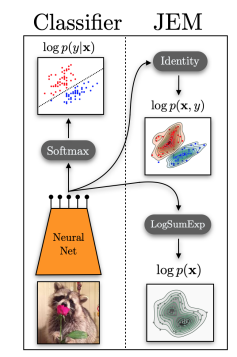

</div>

## Exercise 3.4: JEM Training — Contrastive Loss + Classification Loss

In [ ]:
# ============================================================
#  JEM — Joint Energy-Based Model (PyTorch Lightning)
# ============================================================

class JEM(pl.LightningModule):
    """
    Joint Energy-Based Model combining:
      1. Generative modeling via contrastive divergence (p(x) step)
      2. Discriminative classification via cross-entropy (p(y|x) step)
    """

    def __init__(
        self,
        img_shape,
        batch_size,
        num_classes=42,
        cbuffer_size=256,
        ccond_sample=False,
        alpha=0.1,
        lmbd=0.1,
        lr=1e-4,
        lr_stepsize=1,
        lr_gamma=0.97,
        steps=60,
        step_size_decay=1.0,
        **MODEL_args,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.img_shape = img_shape
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.ccond_sample = ccond_sample

        self.cnn = ShallowCNN(**MODEL_args)
        self.sampler = MCMCSampler(
            self.cnn,
            img_shape=img_shape,
            sample_size=batch_size,
            num_classes=num_classes,
            cbuffer_size=cbuffer_size,
        )
        self.example_input_array = torch.zeros(1, *img_shape)

        # Torchmetrics for evaluation
        metrics = torchmetrics.MetricCollection([
            torchmetrics.CohenKappa(num_classes=num_classes, task='multiclass'),
            torchmetrics.AveragePrecision(num_classes=num_classes, task='multiclass'),
            torchmetrics.AUROC(num_classes=num_classes, task='multiclass'),
            torchmetrics.MatthewsCorrCoef(num_classes=num_classes, task='multiclass'),
            torchmetrics.CalibrationError(task='multiclass', num_classes=num_classes),
        ])
        dyna_metrics = [
            torchmetrics.Accuracy, torchmetrics.Precision,
            torchmetrics.Recall,   torchmetrics.Specificity, torchmetrics.F1Score,
        ]
        self.train_metrics = metrics.clone(prefix='train_')
        self.valid_metrics = metrics.clone(prefix='val_')
        for mode in ['micro', 'macro']:
            self.train_metrics.add_metrics(
                {f"{mode}_{m.__name__}": m(average=mode, num_classes=num_classes, task='multiclass')
                 for m in dyna_metrics})
            self.valid_metrics.add_metrics(
                {f"{mode}_{m.__name__}": m(average=mode, num_classes=num_classes, task='multiclass')
                 for m in dyna_metrics})

    def forward(self, x, labels=None):
        return self.cnn(x, labels)

    def configure_optimizers(self):
        # No momentum: energy surface shifts every step, momentum causes instability
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr, betas=(0.0, 0.999))
        scheduler = optim.lr_scheduler.StepLR(
            optimizer, self.hparams.lr_stepsize, gamma=self.hparams.lr_gamma
        )
        return [optimizer], [scheduler]

    # ── (a) p(x) step: generative loss ─────────────────────────────
    def px_step(self, batch, ccond_sample=True):
        """
        Contrastive Divergence loss for modelling p(x).

        Loss = L2_reg(E_real, E_fake) + ContrastiveDivergence
             = α·(E_real² + E_fake²).mean() + (E_real - E_fake).mean()

        Intuition: push E_real down (↓ energy = ↑ probability of training data)
                   push E_fake up  (↑ energy = ↓ probability of generated data)
        """
        real_imgs, labels = batch

        # Synthesise fake images via SGLD
        clabel = labels if ccond_sample else None
        fake_imgs = self.sampler.synthesize_samples(clabel=clabel, steps=60, step_size=10)

        # Compute energies (unconditional)
        real_energy = self.cnn(real_imgs, y=None)
        fake_energy = self.cnn(fake_imgs, y=None)

        # L2 regularisation: keeps energies from blowing up
        reg_loss  = self.hparams.alpha * (real_energy**2 + fake_energy**2).mean()
        # Contrastive Divergence: E_real < E_fake → real data more probable than noise
        cdiv_loss = real_energy.mean() - fake_energy.mean()
        loss = reg_loss + cdiv_loss

        self.log('train_contrastive_divergence', cdiv_loss, on_step=True, on_epoch=True)
        self.log('train_reg_loss',               reg_loss,  on_step=True, on_epoch=True)
        return loss

    # ── (b) p(y|x) step: classification loss ───────────────────────
    def pyx_step(self, batch):
        """
        Standard cross-entropy loss for modelling p(y|x).
        Uses the same CNN logits — no extra computation needed!
        """
        x, y = batch
        logits = self.cnn.get_logits(x)
        loss = F.cross_entropy(logits, y)

        with torch.no_grad():
            acc = (logits.argmax(1) == y).float().mean()
            self.log('train_acc', acc, on_step=False, on_epoch=True)
        return loss

    # ── (c) Joint training step: log q(x,y) = log q(x) + log q(y|x) ─
    def training_step(self, batch, batch_idx):
        """
        Combines both losses to train the joint density q(x, y).
        Implements the factorisation: log q(x,y) = log q(x) + log q(y|x)
        """
        loss_px  = self.px_step(batch, self.ccond_sample)   # Generative
        loss_pyx = self.pyx_step(batch)                      # Discriminative
        loss = loss_px + loss_pyx                            # Joint
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx, dataset_idx=None):
        x, y = batch
        logits = self.cnn.get_logits(x)
        loss_cls = F.cross_entropy(logits, y)
        self.log('val_loss_cls', loss_cls)
        self.valid_metrics.update(logits, y)

        # Generative proxy: real energy should be lower than noise energy
        noise = torch.rand_like(x) * 2 - 1
        real_energy  = self.cnn(x, y=None)
        noise_energy = self.cnn(noise, y=None)
        val_cdiv = real_energy.mean() - noise_energy.mean()
        self.log('val_contrastive_divergence', val_cdiv)
        self.log_dict(self.valid_metrics, on_step=False, on_epoch=True)

---

## Training the JEM

Training alternates between two steps each mini-batch:
1. **SGLD sampling** — run the Markov chain to get synthetic images
2. **Parameter update** — contrastive divergence + cross-entropy gradient step

> **Note:** Training typically takes several hours due to the SGLD inner loop (60 steps per mini-batch). Use a checkpoint if available.

Key hyperparameters:

| Parameter | Default | Description |
|---|---|---|
| `lr` | `1e-4` | Adam learning rate (no momentum: `β₁=0`) |
| `alpha` | `0.1` | L2 regularisation strength |
| `cbuffer_size` | `128` | Max images per class in replay buffer |
| `steps` | `60` | SGLD steps per mini-batch |
| `num_epochs` | `120` | Training epochs |

In [ ]:
def run_training(
    data_dir="./data/GLYPHS",
    ckpt_dir="./models",
    batch_size=32,
    num_epochs=120,
    num_classes=42,
    lr=1e-4,
    lr_stepsize=2,
    lr_gamma=0.97,
    alpha=0.1,
    cbuffer_size=128,
    ccond_sample=False,
    num_workers=0,
):
    os.makedirs(ckpt_dir, exist_ok=True)
    datasets = get_datasets(data_dir)

    train_loader = data.DataLoader(
        datasets['train'], batch_size=batch_size, shuffle=True,
        drop_last=True, num_workers=num_workers, pin_memory=True
    )
    val_loader = data.DataLoader(
        datasets['val'], batch_size=batch_size, shuffle=False,
        drop_last=False, num_workers=num_workers
    )

    pl.seed_everything(42)
    model = JEM(
        img_shape=(1, 56, 56),
        batch_size=batch_size,
        num_classes=num_classes,
        hidden_features=32,
        cbuffer_size=cbuffer_size,
        ccond_sample=ccond_sample,
        lr=lr,
        lr_gamma=lr_gamma,
        lr_stepsize=lr_stepsize,
        alpha=alpha,
        step_size_decay=1.0,
        num_epochs=num_epochs,
    )

    trainer = pl.Trainer(
        default_root_dir=ckpt_dir,
        max_epochs=num_epochs,
        gradient_clip_val=0.1,
        callbacks=[
            ModelCheckpoint(save_weights_only=True, mode="min",
                            monitor='val_contrastive_divergence',
                            filename='val_condiv_{epoch}-{step}'),
            ModelCheckpoint(save_weights_only=True, mode="max",
                            monitor='val_MulticlassAveragePrecision',
                            filename='val_mAP_{epoch}-{step}'),
            ModelCheckpoint(save_weights_only=True, filename='last_{epoch}-{step}'),
            LearningRateMonitor("epoch"),
        ]
    )

    trainer.fit(model, train_loader, val_loader)
    return JEM.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)


# ── To train from scratch, uncomment the line below:
# model = run_training(data_dir="./data/GLYPHS", ckpt_dir="./models")

print("Training function defined. Uncomment the last line to start training.")

In [ ]:
# ── Load from checkpoint ────────────────────────────────────
def find_best_checkpoint(base_dir):
    """Find the best available checkpoint, prioritising val_mAP > val_condiv > last."""
    all_ckpts = glob.glob(os.path.join(base_dir, "**", "*.ckpt"), recursive=True)
    if not all_ckpts:
        return None
    for keyword in ["val_mAP", "val_condiv", "last"]:
        matches = [c for c in all_ckpts if keyword in os.path.basename(c)]
        if matches:
            return max(matches, key=os.path.getmtime)
    return max(all_ckpts, key=os.path.getmtime)


CKPT_DIR = "./models"
ckpt_path = find_best_checkpoint(CKPT_DIR)

if ckpt_path:
    print(f"Found checkpoint: {ckpt_path}")
    model = JEM.load_from_checkpoint(ckpt_path)
    model.to(device)
    model.eval()
    print("Model loaded successfully!")
else:
    print("No checkpoint found. Run run_training() first or specify CKPT_DIR.")

---

## Exercise 3.5: Synthesising New Images

Once trained, we can use the EBM as a **latent generative model**: start from Gaussian noise and follow the energy gradient toward low-energy (high-probability) regions.

Using more SGLD steps ($K = 256$ or $512$) during generation than during training ($K = 60$) produces higher-quality images.

In [ ]:
def run_generation(model, conditional=False, num_steps=256, batch_size=8, step_size=10):
    """
    Generate new glyph images by running SGLD from Gaussian noise.

    Args:
        model:       Trained JEM
        conditional: If True, generate conditioned on specific class labels
        num_steps:   Number of SGLD mixing steps (more → higher quality)
        batch_size:  Number of images per label
        step_size:   SGLD step size
    """
    model.eval()
    torch.set_grad_enabled(True)
    pl.seed_everything(42)

    # Select a few interesting class labels to visualise
    class_labels = [1, 4, 5, 10, 17, 18, 23, 39]
    n_steps_display = 8
    step_interval = num_steps // n_steps_display

    all_final_imgs = []

    for label in tqdm.tqdm(class_labels, desc="Generating"):
        clabel = (torch.ones(batch_size) * label).long().to(device) if conditional else None

        mcmc = MCMCSampler(model, model.img_shape, batch_size, model.num_classes)
        imgs = mcmc.synthesize_samples(
            clabel, steps=num_steps, step_size=step_size, return_img_per_step=True
        ).cpu()  # (num_steps, B, C, H, W)

        all_final_imgs.append(imgs[-1])  # Keep final result

        # ── Plot synthesis progression for one sample ─────────────
        sample_idx = 0
        snapshots = imgs[step_interval - 1::step_interval, sample_idx]   # (n_steps_display, C, H, W)
        snapshots = torch.cat([imgs[0:1, sample_idx], snapshots], dim=0)
        grid = torchvision.utils.make_grid(
            snapshots, nrow=snapshots.shape[0],
            normalize=True, value_range=(-1, 1), pad_value=0.5, padding=2
        ).permute(1, 2, 0)

        fig, ax = plt.subplots(figsize=(10, 2))
        ax.imshow(grid, cmap='gray')
        ax.set_xlabel("Generation step")
        steps_shown = [1] + list(range(step_interval, num_steps + 1, step_interval))
        ax.set_xticks([(grid.shape[1] / len(steps_shown)) * (0.5 + j) for j in range(len(steps_shown))],
                      labels=steps_shown)
        ax.set_yticks([])
        mode = "Conditional" if conditional else "Unconditional"
        ax.set_title(f"{mode} generation — class {label}")
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"{mode.lower()}_label{label}.png"), dpi=100)
        plt.show()

    # ── Plot all final results in a grid ─────────────────────────
    final_grid = torchvision.utils.make_grid(
        torch.cat(all_final_imgs), nrow=batch_size,
        normalize=True, value_range=(-1, 1), pad_value=0.5, padding=2
    ).permute(1, 2, 0)[..., 0].numpy()

    fig, ax = plt.subplots(figsize=(14, len(class_labels) * 2))
    ax.imshow(final_grid, cmap='Greys')
    ax.axis('off')
    ax.set_title(f"{mode} synthesis — {num_steps} SGLD steps", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{mode.lower()}_final_grid.png"), dpi=100)
    plt.show()

    torch.set_grad_enabled(False)


# ── Run generation (requires a trained model) ──────────────
if ckpt_path:
    # (a) Conditional generation (class-specific)
    run_generation(model, conditional=True,  num_steps=256)
    # (b) Unconditional generation
    run_generation(model, conditional=False, num_steps=256)

---

## Exercise 3.6: Out-of-Distribution (OOD) Detection

EBMs have a natural interpretation as OOD detectors: the energy $E_\theta(\mathbf{x})$ is low for in-distribution data and high for OOD samples.

We define the **score function**:
$$s_\theta(\mathbf{x}) = -E_\theta(\mathbf{x}) = \log\sum_y \exp(f_\theta(\mathbf{x})[y])$$

High score → likely in-distribution. Low score → likely OOD.

We evaluate on:
- **ID (test set):** Real glyph images, expected to have high scores
- **OOD Type A:** Different distribution with some visual similarity
- **OOD Type B:** Another OOD distribution
- **OOD Noise:** Pure uniform random noise — should be easiest to detect

We measure performance using the **AUROC** metric (threshold-independent).

In [ ]:
# ============================================================
#  ood.py — Score functions for OOD detection
# ============================================================

def grad_norm(model, x, y=None):
    """Score based on the L2 norm of the energy gradient w.r.t. input (mass score)."""
    had_grads = torch.is_grad_enabled()
    torch.set_grad_enabled(True)
    x_k = torch.autograd.Variable(x, requires_grad=True)
    f_prime = torch.autograd.grad(model.cnn(x_k, y=y).sum(), [x_k], retain_graph=True)[0]
    grad = f_prime.view(x.size(0), -1)
    torch.set_grad_enabled(had_grads)
    return grad.norm(p=2, dim=1)


def score_fn(model, x, y=None, score="px"):
    """
    Compute OOD score for a batch of images.

    Args:
        score: One of:
            'px'   → negative energy: -E(x) = log ΣexpF(x) (higher = more likely ID)
            'py'   → max softmax probability: max_y p(y|x)  (higher = more confident)
            'mass' → gradient norm: ||∇_x E(x)||₂           (higher = steeper energy)
    """
    if score == "px":
        return -model.cnn(x, y).detach().cpu()
    elif score == "py":
        return F.softmax(model.cnn.get_logits(x), dim=1).max(1)[0].detach().cpu()
    elif score == "mass":
        return -grad_norm(model, x, y).detach().cpu()
    else:
        raise ValueError(f"Unknown score function: {score}")

In [ ]:
def run_ood_analysis(model, data_dir="./data/GLYPHS", batch_size=32, num_workers=0):
    """
    (a) Compute energy scores for ID and OOD data
    (b) Visualise score distributions as histograms
    (c) Evaluate binary OOD classification via AUROC
    """
    model.eval()
    pl.seed_everything(42)
    datasets = get_datasets(data_dir)

    loaders = {
        'Real (ID Test)': data.DataLoader(datasets['test'],      batch_size=batch_size, shuffle=False, num_workers=num_workers),
        'OOD Type A':     data.DataLoader(datasets['ood_ta'],    batch_size=batch_size, shuffle=False, num_workers=num_workers),
        'OOD Type B':     data.DataLoader(datasets['ood_tb'],    batch_size=batch_size, shuffle=False, num_workers=num_workers),
        'OOD Noise':      data.DataLoader(datasets['ood_noise'], batch_size=batch_size, shuffle=False, num_workers=num_workers),
    }

    # ── (a) Compute scores ─────────────────────────────────────
    all_scores = {}
    for name, loader in loaders.items():
        scores = []
        with torch.no_grad():
            for x, _ in tqdm.tqdm(loader, desc=f"Scoring {name}"):
                scores.append(score_fn(model, x.to(device), score="px"))
        all_scores[name] = torch.cat(scores).numpy()
        print(f"  {name:20s}: mean score = {all_scores[name].mean():.3f}")

    # ── (b) Visualise distributions ────────────────────────────
    colours = ['steelblue', 'darkorange', 'seagreen', 'crimson']
    fig, ax = plt.subplots(figsize=(12, 5))
    for (name, scores), color in zip(all_scores.items(), colours):
        sns.histplot(scores, label=name, kde=True, stat="density",
                     color=color, alpha=0.35, ax=ax)
    ax.axvline(0, color='black', linestyle='--', alpha=0.4, label='threshold = 0')
    ax.set_xlabel("Score  [higher = more likely in-distribution]", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title("Energy-based Score Distributions — ID vs OOD", fontsize=14)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "ood_histogram.png"), dpi=150)
    plt.show()

    # ── (c) AUROC evaluation ───────────────────────────────────
    print("\nAUROC Results (ID=0, OOD=1):")
    id_scores = all_scores['Real (ID Test)']
    results = {}
    for name in ['OOD Type A', 'OOD Type B', 'OOD Noise']:
        ood_scores = all_scores[name]
        y_true  = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
        y_score = np.concatenate([id_scores, ood_scores])
        # Negate: high score = ID (label 0), so OOD (label 1) has low score → negate for correct AUROC
        auroc = roc_auc_score(y_true, -y_score)
        results[name] = auroc
        print(f"  ID vs {name:15s}: AUROC = {auroc:.4f}")

    # Bar chart of AUROC scores
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(list(results.keys()), list(results.values()),
                  color=['darkorange', 'seagreen', 'crimson'], alpha=0.8, edgecolor='black')
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Random classifier')
    ax.set_ylabel("AUROC", fontsize=12)
    ax.set_title("OOD Detection Performance (AUROC)", fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "ood_auroc.png"), dpi=150)
    plt.show()

    return results


# ── Run OOD analysis ────────────────────────────────────────
if ckpt_path:
    ood_results = run_ood_analysis(model, data_dir="./data/GLYPHS")

---

## Summary

In this notebook, we implemented and explored a complete **Energy-Based Model** pipeline:

| Component | Key Idea |
|---|---|
| **EBM** | Model $q_\theta(\mathbf{x}) \propto \exp(-E_\theta(\mathbf{x}))$ with a CNN |
| **SGLD** | Approximate partition function via gradient-guided MCMC sampling |
| **Reservoir sampling** | Stabilise training by mixing fresh noise with past synthetic images |
| **JEM** | Repurpose classifier logits as joint density — train generatively *and* discriminatively |
| **Image synthesis** | Generate new glyphs by starting from noise and following energy gradients |
| **OOD detection** | Use energy as a score to separate in-distribution from OOD samples |

### Further Reading
- Grathwohl et al. (2020) — [Your Classifier is Secretly an EBM](https://arxiv.org/abs/1912.03263)
- Du & Mordatch (2019) — [Implicit Generation and Modeling with EBMs](https://arxiv.org/abs/1903.08689)
- UvA DL Tutorial — [Deep Energy-Based Models](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html)